In [321]:
# WHETHER BLOOD PRESSURE COULD BE A PREDICTIVE RISK FACTOR FOR CVD?

#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [322]:
#load dataset
data= pd.read_csv("Cardiovascular_Disease_Dataset.csv")

In [323]:
print(data)

     patientid  age  gender  chestpain  restingBP  serumcholestrol  \
0       103368   53       1          2        171                0   
1       119250   40       1          0         94              229   
2       119372   49       1          2        133              142   
3       132514   43       1          0        138              295   
4       146211   31       1          1        199                0   
..         ...  ...     ...        ...        ...              ...   
995    9949544   48       1          2        139              349   
996    9953423   47       1          3        143              258   
997    9965859   69       1          0        156              434   
998    9988507   45       1          1        186              417   
999    9990855   25       1          0        158              270   

     fastingbloodsugar  restingrelectro  maxheartrate  exerciseangia  oldpeak  \
0                    0                1           147              0      5.3 

In [324]:
print(data.shape)

(1000, 14)


In [325]:
print(data.columns)

Index(['patientid', 'age', 'gender', 'chestpain', 'restingBP',
       'serumcholestrol', 'fastingbloodsugar', 'restingrelectro',
       'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels',
       'target'],
      dtype='str')


##DATA CLEANING

In [326]:
data.isna().sum()

patientid            0
age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64

In [327]:
data.duplicated().sum()

np.int64(0)

In [328]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB


In [329]:
data.describe()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
count,1.000000e+03,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.048704e+06,49.24200,0.765000,0.980000,151.747000,311.447000,0.296000,0.748000,145.477000,0.498000,2.707700,1.540000,1.222000,0.580000
std,2.895905e+06,17.86473,0.424211,0.953157,29.965228,132.443801,0.456719,0.770123,34.190268,0.500246,1.720753,1.003697,0.977585,0.493805
min,1.033680e+05,20.00000,0.000000,0.000000,94.000000,0.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.536440e+06,34.00000,1.000000,0.000000,129.000000,235.750000,0.000000,0.000000,119.750000,0.000000,1.300000,1.000000,0.000000,0.000000
50%,4.952508e+06,49.00000,1.000000,1.000000,147.000000,318.000000,0.000000,1.000000,146.000000,0.000000,2.400000,2.000000,1.000000,1.000000
75%,7.681877e+06,64.25000,1.000000,2.000000,181.000000,404.250000,1.000000,1.000000,175.000000,1.000000,4.100000,2.000000,2.000000,1.000000
max,9.990855e+06,80.00000,1.000000,3.000000,200.000000,602.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


In [330]:
## Minimum value of Serum cholestrol is 0. So removing that row
data['serumcholestrol'] = data['serumcholestrol'].replace(0, np.nan)
data = data.dropna(subset=['serumcholestrol'])
print(f"Minimum cholesterol value: {data['serumcholestrol'].min()} mg/dL")

Minimum cholesterol value: 85.0 mg/dL


In [331]:
data.describe()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
count,9.470000e+02,947.000000,947.000000,947.000000,947.000000,947.000000,947.000000,947.000000,947.000000,947.000000,947.000000,947.000000,947.000000,947.000000
mean,5.081857e+06,49.300950,0.764520,0.972545,151.072862,328.877508,0.312566,0.730729,145.009504,0.502640,2.700845,1.504752,1.202746,0.556494
std,2.886946e+06,17.887398,0.424523,0.958596,30.068877,113.073251,0.463784,0.765492,34.475762,0.500257,1.706826,1.007755,0.975965,0.497061
min,1.192500e+05,20.000000,0.000000,0.000000,94.000000,85.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.545688e+06,34.000000,1.000000,0.000000,128.000000,248.000000,0.000000,0.000000,118.000000,0.000000,1.300000,1.000000,0.000000,0.000000
50%,4.994167e+06,49.000000,1.000000,1.000000,144.000000,326.000000,0.000000,1.000000,145.000000,1.000000,2.400000,2.000000,1.000000,1.000000
75%,7.697459e+06,65.000000,1.000000,2.000000,180.500000,410.000000,1.000000,1.000000,175.000000,1.000000,4.100000,2.000000,2.000000,1.000000
max,9.990855e+06,80.000000,1.000000,3.000000,200.000000,602.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


**##FUNCTIONS**

In [332]:
def plot_countplot(data, column_name):

    plt.figure(figsize=(5, 5))
    sns.countplot(x=column_name, data=data, hue= column_name, legend= False)
    plt.xlabel(column_name.capitalize(), fontsize=11)
    plt.ylabel("Count", fontsize=11)
    plt.title(f"Distribution of {column_name.capitalize()}", fontsize=12, fontweight='bold')

    plt.show()


In [333]:
def numeric_feature_countplot(data, column_name):
    plt.figure(figsize=(5,5))
    sns.countplot(data=data,x=column_name,hue='target')
    plt.legend(['Healthy', 'CVD'])
    plt.title(f"{column_name.capitalize()}- Healthy VS CVD", fontsize=12, fontweight='bold')

    plt.show()

In [334]:
def plot_histogram(data, column_name):

    plt.figure(figsize=(5, 5))
    sns.histplot(x=column_name, data=data, bins=30, kde=True)
    plt.xlabel(column_name.title(), fontsize=11)
    plt.ylabel("Frequency", fontsize=11)
    plt.title(f"Distribution of {column_name.title()}", fontsize=12, fontweight='bold')

    plt.show()

In [335]:
def boxplot(data, column_name):

    plt.figure(figsize=(5,5))
    sns.boxplot( x='target', y=column_name, data=data)
    plt.xlabel("target", fontsize=11)
    plt.ylabel(column_name.title(), fontsize=11)
    plt.title(f" {column_name.title()}- Healthy VS CVD", fontsize=12, fontweight='bold')

    plt.show()

In [336]:
def boxplot_1(data, column_name):

    plt.figure(figsize=(5,5))
    sns.boxplot( x='gender', y=column_name, data=data, hue= 'target')
    plt.xlabel("gender", fontsize=11)
    plt.ylabel(column_name.title(), fontsize=11)
    plt.title(f" {column_name.title()}:Gender", fontsize=12, fontweight='bold')

    plt.show()

In [337]:
def scatterplot(data, variable1, variable2):

    plt.figure(figsize=(5,5))
    sns.scatterplot(x=variable1, y=variable2, hue='target', data=data)
    plt.xlabel(variable1.title(), fontsize=11)
    plt.ylabel(variable2.title(), fontsize=11)

    plt.show()

In [338]:
def lmplot(data, variable1, variable2):

    plt.figure(figsize=(5,5))
    sns.lmplot(x=variable1, y=variable2, hue='target', data=data)
    plt.xlabel(variable1.title(), fontsize=11)
    plt.ylabel(variable2.title(), fontsize=11)

    plt.show()

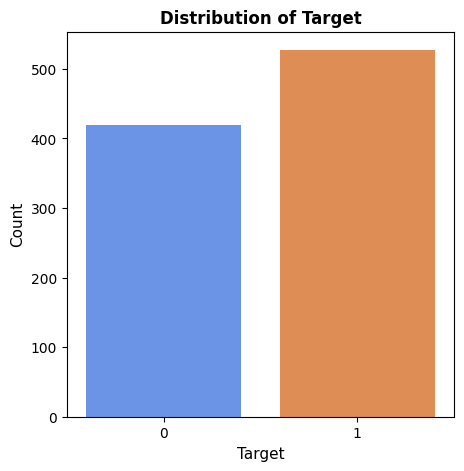

In [339]:
#Distribution of Healthy VS CVD
plot_countplot(data=data, column_name='target')

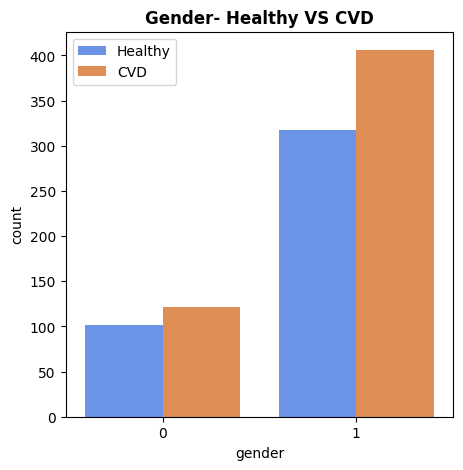

In [340]:
#gender pattern
numeric_feature_countplot(data=data, column_name='gender')

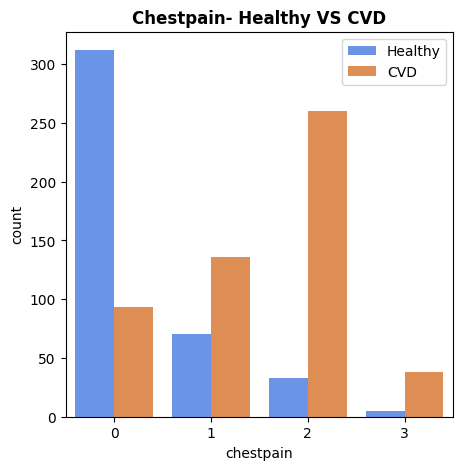

In [341]:
numeric_feature_countplot(data=data, column_name='chestpain')

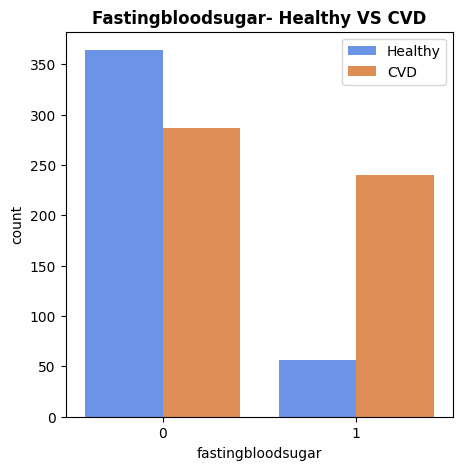

In [342]:
numeric_feature_countplot(data=data, column_name='fastingbloodsugar')

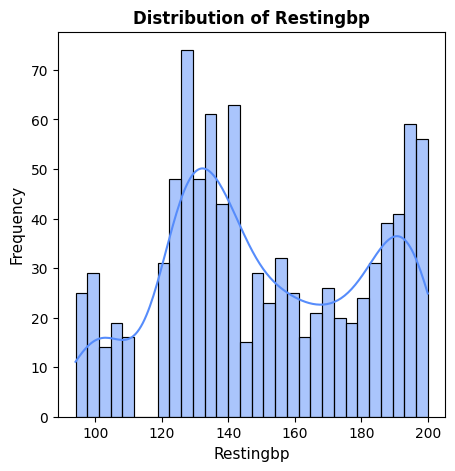

In [343]:
#Resting BP across samples
plot_histogram(data=data, column_name='restingBP')

In [344]:
#which variable is strongly correlated?
correlation = data.corr(numeric_only=True)
print(correlation['target'].sort_values(ascending=False))

target               1.000000
slope                0.801906
chestpain            0.571200
noofmajorvessels     0.497155
restingBP            0.484307
restingrelectro      0.430355
serumcholestrol      0.377729
fastingbloodsugar    0.345184
maxheartrate         0.225461
oldpeak              0.100120
gender               0.015521
age                  0.011699
patientid            0.004325
exerciseangia       -0.033547
Name: target, dtype: float64


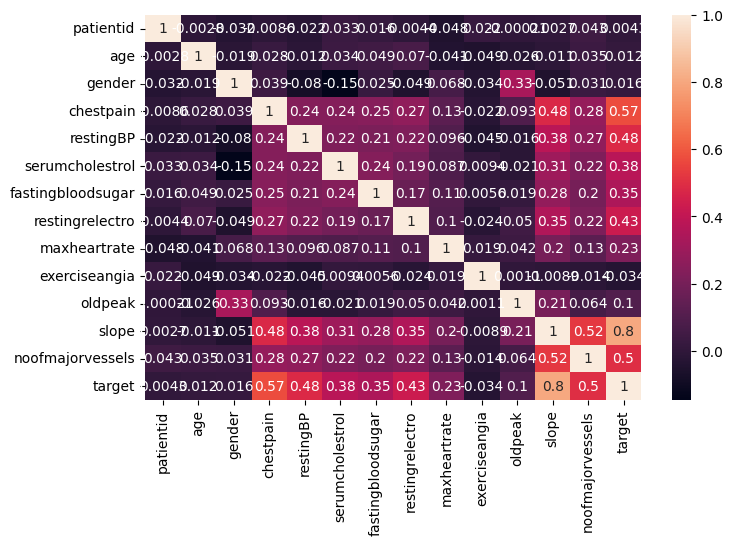

In [345]:
##correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(correlation,annot=True)
plt.show()

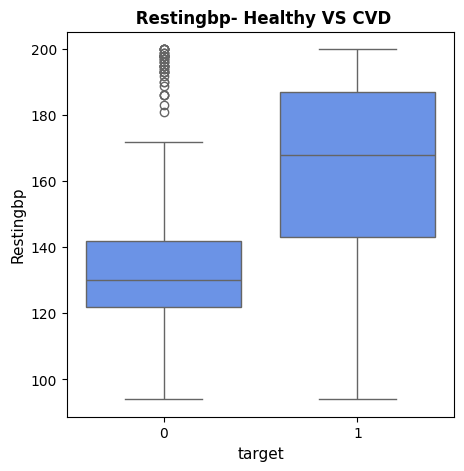

In [346]:
#Resting BP level differences in Healthy VS CVD
boxplot(data=data, column_name='restingBP')

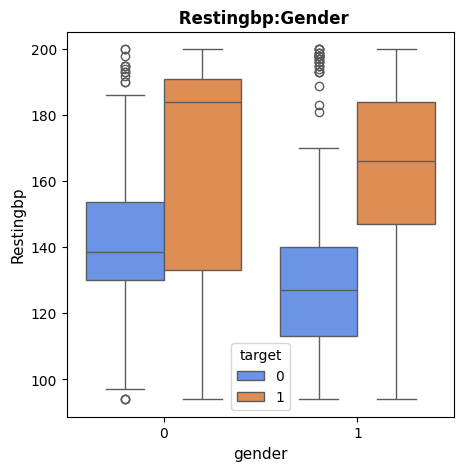

In [347]:
#BP across gender
boxplot_1(data=data, column_name='restingBP')

<Figure size 500x500 with 0 Axes>

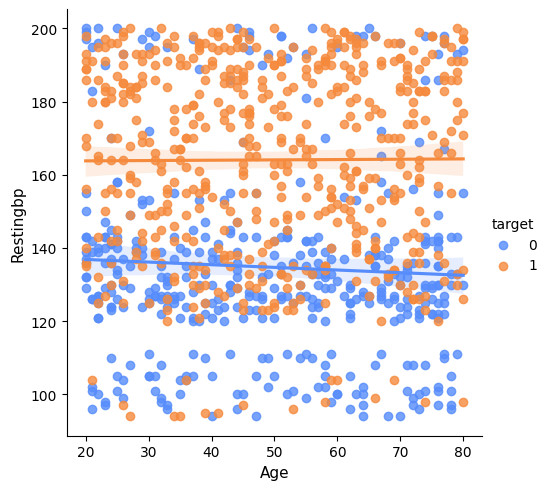

In [348]:
#realtionship between age and resting BP
lmplot(data=data, variable1='age', variable2='restingBP')

<Figure size 500x500 with 0 Axes>

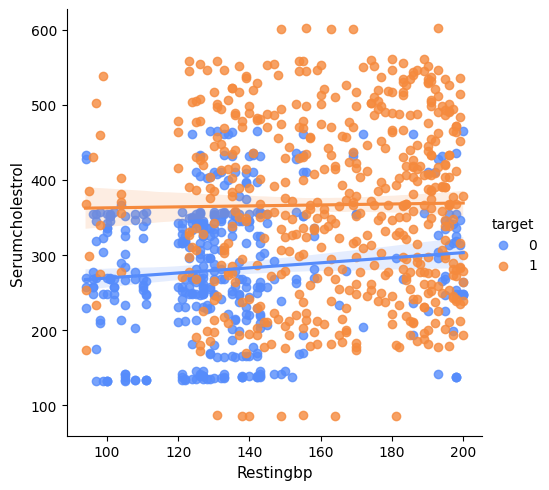

In [349]:
#relationship between resting BP and serumchoelstrol
lmplot(data=data, variable1='restingBP', variable2='serumcholestrol')

<Figure size 500x500 with 0 Axes>

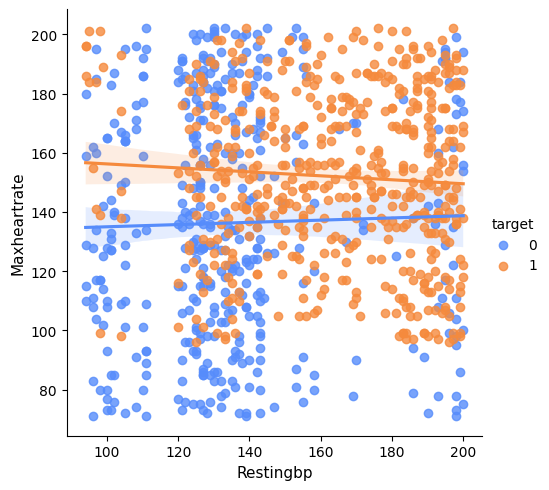

In [350]:
#relationship between resting BP and max heart rate
lmplot(data=data, variable1='restingBP', variable2='maxheartrate')

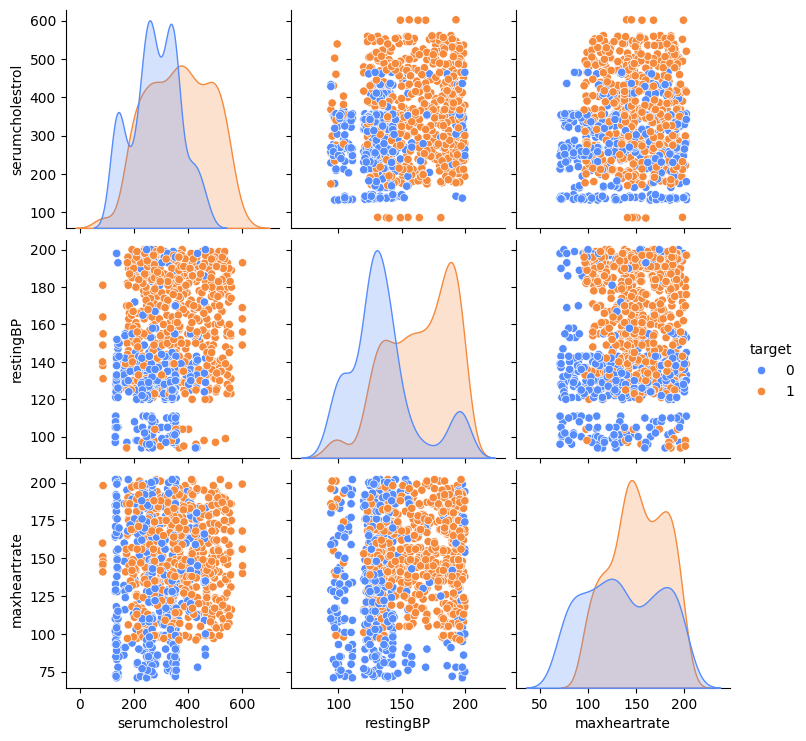

In [351]:
# Plots scatter correlations for all three variables simultaneously
sns.pairplot(
    data=data,
    vars=['serumcholestrol', 'restingBP', 'maxheartrate'],
    hue='target'
)
plt.show()

In [352]:
#Mean value of Resting BP
cvd = data[data["target"]==1]
healthy = data[data["target"]==0]

print("Mean RestingBP in CVD:", cvd['restingBP'].mean())
print("Mean RestingBP in Healthy:", healthy['restingBP'].mean())

Mean RestingBP in CVD: 164.06641366223909
Mean RestingBP in Healthy: 134.76904761904763


In [353]:
 #Performing T test
from scipy import stats

healthy = data[data['target'] == 0]['restingBP']
cvd = data[data['target'] == 1]['restingBP']

t_stat, p_value = stats.ttest_ind(healthy, cvd)
print(f"\n  T-test p-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"Significant difference (p < 0.05)")
else:
    print(f"Not significant (p >= 0.05)")


  T-test p-value: 0.0000
Significant difference (p < 0.05)


**LOGISTIC REGRESSION**

In [354]:
import sklearn
import scipy

In [373]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data[['restingBP']]
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.1%}")

Accuracy: 76.8%


In [370]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[76 12]
 [30 72]]
              precision    recall  f1-score   support

           0       0.72      0.86      0.78        88
           1       0.86      0.71      0.77       102

    accuracy                           0.78       190
   macro avg       0.79      0.78      0.78       190
weighted avg       0.79      0.78      0.78       190

